# Test GAN 

In [15]:
%matplotlib inline

import os 
import sys 
import numpy as np 
import torch 
import random
import joblib
import pandas as pd


parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from src.dataset.custom_dataset import GenDataset, DiscDataset
from src.model.graph_model import NEGATGenerator, DiffPoolDiscriminator
from src.training.trainer import train_GAN

from utils.gen_utils import load_config, get_device, dataset_splitter, generate_markdown_report_GAN_and_save_model
from utils.ppnet_utils import initialize_network
from utils.load_data_utils import load_sampled_input_data

### Initialise the configuration and data for G and D 

In [ ]:
# # find the best seed values from the latest results
# generated_data = joblib.load(parent_dir + f'/results/GAN_only/Oct2_all_seed_generated_data.pkl')
# simulated_v_pf_data = joblib.load(parent_dir + f'/results/GAN_only/Oct2_all_seed_simulated_v_pf_data.pkl')
# all_losses_seeds = joblib.load(parent_dir + f'/results/GAN_only/Oct2_all_seed_losses_data.pkl')
# seeds = np.arange(len(generated_data.keys()))

# generated_v_df = pd.DataFrame(columns=seeds)
# simulated_v_pf_data_df = pd.DataFrame(columns=seeds)
# all_val_g_losses_df = pd.DataFrame(columns=seeds)
# all_val_d_losses_df = pd.DataFrame(columns=seeds)
# all_val_d_accuracies_df = pd.DataFrame(columns=seeds)

# num_buses = 42

# for seed in seeds: 
#     all_val_g_losses_df[seed] = all_losses_seeds[seed]['val_g_losses']
#     all_val_d_losses_df[seed] = all_losses_seeds[seed]['val_d_losses']
#     all_val_d_accuracies_df[seed] = all_losses_seeds[seed]['val_d_accuracies']
#     try: 
#         generated_v_df[seed] = generated_data[seed]['gen_v'][:num_buses]
#         simulated_v_pf_data_df[seed] = simulated_v_pf_data[seed]
#     except Exception as e: 
#         print(e)
       
# generated_v_df.dropna(axis='columns', inplace=True)
# simulated_v_pf_data_df.dropna(axis='columns', inplace=True)

# gen_minus_sim = generated_v_df - simulated_v_pf_data_df

# # ignore nans
# abs_diff_sum = gen_minus_sim.abs().sum(axis=0, skipna=True)
# best_seed = int(abs_diff_sum.idxmin())  # returns the actual seed, not column index

# print(f"The seed with minimum difference between generated and simulated voltage magnitude: {best_seed}")

'int' object is not subscriptable
The seed with minimum difference between generated and simulated voltage magnitude: 19


In [ ]:
# random.seed(best_seed)
# np.random.seed(best_seed)
# torch.manual_seed(best_seed)

yaml_config= load_config('config_gan.yaml')

device = get_device(yaml_config['device'])

net = initialize_network(net_name=yaml_config['data']['net_name'],
                         load_std=yaml_config['data']['load_std']) 


Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 



In [ ]:
########### data for generator 
sampled_input_data_G = load_sampled_input_data(sc_type=yaml_config['data']['gen_scenario_type'], 
                                               net=net, 
                                               num_samples=yaml_config['data']['num_samples'], 
                                               noise=yaml_config['data']['noise'])
# joblib.dump(sampled_input_data_G,  os.getcwd() +  '/sampled_input_data_G.pkl')
# sampled_input_data_G = joblib.load(os.getcwd() +  '/sampled_input_data_G.pkl')

########### data for discriminator 
sampled_input_data_D = load_sampled_input_data(sc_type=yaml_config['data']['dis_scenario_type'], 
                                               net=net, 
                                               num_samples=yaml_config['data']['num_samples'], 
                                               noise=yaml_config['data']['noise'])
# joblib.dump(sampled_input_data_D, os.getcwd() +  '/sampled_input_data_D.pkl')
# sampled_input_data_D = joblib.load(os.getcwd() +  '/sampled_input_data_D.pkl')

Selecting all the MV/LV transformers in the network 


 Embedding real measurement locations for Net-A

Scaling inputs...
Number of V, P measurements 18 out of 84

Number of P_to, Q_to, P_from, Q_from measurements 12 out of 42

Sparsity of PV measurements at buses = 0.2%
Sparsity of P+ measurements at branches = 0.3
Sparsity of PV measurements at buses = 0.2%
Sparsity of P+ measurements at branches = 0.3
Scaling inputs...


### Make dataset and dataloader

In [5]:
dataset_G = GenDataset(model_name=yaml_config['model_G']['name'], 
                       sampled_input_data=sampled_input_data_G)

(train_loader_G, val_loader_G, test_loader_G), _ = dataset_splitter(dataset_G, 
                                                                    batch_size=yaml_config['loader']['batch_size'])

dataset_D = DiscDataset(sampled_input_data=sampled_input_data_D)

(train_loader_D, val_loader_D, test_loader_D), _ = dataset_splitter(dataset_D,
                                                                    batch_size=yaml_config['loader']['batch_size'])


Dataset for NEGATGenerator selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...



### Instantiate the model, optimizer, schedular 

In [6]:
# instantiate model, optimizer and schedular for Generator 
model_G = NEGATGenerator(node_input_features=dataset_G[0][0].x.shape[-1], 
                    list_node_hidden_features=yaml_config['model_G']['list_node_hidden_features'], # [128,64], 
                    node_out_features=yaml_config['model_G']['node_out_features'], # 64, 
                    k_hop_node=yaml_config['model_G']['k_hop_node'], #1, 
                    edge_input_features=dataset_G[0][1].x.shape[-1], 
                    list_edge_hidden_features=yaml_config['model_G']['list_edge_hidden_features'], #[128,64], 
                    edge_output_features=yaml_config['model_G']['edge_out_features'], #64, 
                    k_hop_edge=yaml_config['model_G']['k_hop_edge'], #1, 
                    gat_out_features=yaml_config['model_G']['gat_out_features'], #32, 
                    gat_head=yaml_config['model_G']['gat_head'], #2, 
                    device=device)

optimizer_G = torch.optim.Adam(model_G.parameters(), 
                            lr=yaml_config['training_G']['lr'], 
                            weight_decay=yaml_config['training_G']['weight_decay'])

schedular_G = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_G, 
                                                    mode='min', 
                                                    factor=0.1, 
                                                    min_lr=yaml_config['training_G']['schedular_min_lr'])

total_params_G = sum(p.numel() for p in model_G.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model_G}: {total_params_G}')

# instantiate model, optimizer and schedular for Discriminator 
model_D = DiffPoolDiscriminator(in_channel=dataset_D[0].x.shape[-1], 
                            hidden_channel=yaml_config['model_D']['hidden_channel'], 
                            out_channel=yaml_config['model_D']['out_channel'], 
                            num_nodes=len(net.bus.index))

total_params_D = sum(p.numel() for p in model_D.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model_D}: {total_params_D}')

optimizer_D = torch.optim.Adam(model_D.parameters(), 
                            lr=yaml_config['training_D']['lr'], 
                            weight_decay=yaml_config['training_D']['weight_decay'])

schedular_D = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_D, 
                                                    mode='min', 
                                                    factor=0.1, 
                                                    min_lr=yaml_config['training_D']['schedular_min_lr'])


Total number of parameters of model NEGATGenerator(
  (node_layers): ModuleList(
    (0): TAGConv(2, 64, K=3)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (fc_node): Linear(in_features=64, out_features=32, bias=True)
  (edge_layers): ModuleList(
    (0): ModuleList(
      (0-1): 2 x TAGConv(6, 128, K=1)
    )
  )
  (edge_biases): ParameterList(  (0): Parameter containing: [torch.float32 of size 128])
  (fc_edge): Linear(in_features=128, out_features=1, bias=True)
  (gatconv): GATConv(32, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
): 7363
Total number of parameters of model DiffPoolDiscriminator(): 2123


### Train the GAN 

In [7]:
all_losses = train_GAN(model_G=model_G, 
                        model_D=model_D, 
                        all_loader_G= [train_loader_G, val_loader_G, test_loader_G], 
                        all_loader_D= [train_loader_D, val_loader_D, test_loader_D],  
                        optimizer_G=optimizer_G, 
                        optimizer_D=optimizer_D, 
                        schedular_G=schedular_G, 
                        schedular_D=schedular_D, 
                        num_epoch=yaml_config['training_GAN']['num_epoch'], 
                        disc_iter=yaml_config['training_GAN']['disc_iter'], 
                        gen_iter=yaml_config['training_GAN']['gen_iter'],
                        feature_matching=yaml_config['training_GAN']['feature_matching'], 
                        label_smoothing=yaml_config['training_GAN']['label_smoothing'],
                        device=device)  

At epoch: 0
training: D = 2.057e+00, Acc = 0.25, G = 2.321e+01
validation: D = 1.751e+00, Acc = 0.25, G = 1.178e+01, lr_D = 1.0e-05, lr_G 1.0e-04
------------------------------------------------------------------------------
At epoch: 2
training: D = 9.351e-01, Acc = 0.25, G = 3.449e+00
validation: D = 1.215e+00, Acc = 0.25, G = 2.414e+00, lr_D = 1.0e-05, lr_G 1.0e-04
------------------------------------------------------------------------------
At epoch: 4
training: D = 7.855e-01, Acc = 0.25, G = 1.526e+00
validation: D = 1.089e+00, Acc = 0.25, G = 1.569e+00, lr_D = 1.0e-05, lr_G 1.0e-04
------------------------------------------------------------------------------
At epoch: 6
training: D = 7.082e-01, Acc = 0.25, G = 1.342e+00
validation: D = 1.012e+00, Acc = 0.25, G = 1.388e+00, lr_D = 1.0e-05, lr_G 1.0e-04
------------------------------------------------------------------------------
At epoch: 8
training: D = 6.913e-01, Acc = 0.25, G = 1.307e+00
validation: D = 9.867e-01, Acc = 0.25

### Results 

Saved in `results/GAN_results/{current_time}`

In [8]:
from datetime import datetime
current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
report_dir_gan = f"{parent_dir}/results/{current_time}/GAN"
generated_data, simulated_v_pf = generate_markdown_report_GAN_and_save_model(report_dir=report_dir_gan,
                                                                yaml_config=yaml_config, 
                                                                train_g_losses=all_losses['train_g_losses'], 
                                                                train_d_losses=all_losses['train_d_losses'], 
                                                                train_d_accuracies=all_losses['train_d_accuracies'], 
                                                                test_loader_G=test_loader_G, 
                                                                model_G=model_G, 
                                                                sampled_input_data_G=sampled_input_data_G, 
                                                                return_data=True) 

Forward pass calculated!
Inverse scale done!
Mean and variances calculated!
Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 

Plotted real vs. generated line-bar plots!
Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 

Power Flow Converged!
KDE plots failed!: QuadMesh.set() got an unexpected keyword argument 'fontsize'
📄 Training report saved to: /Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/results/20251003_182618/GAN/training_report.md


In [9]:
gen_v = generated_data['gen_v'][:42]
sim_v = simulated_v_pf

In [10]:
sim_v

array([1.02      , 1.02      , 1.02099775, 1.02019337, 1.02102437,
       1.02184158, 1.02125411, 1.02146047, 1.02241915, 1.02282866,
       1.02015607, 1.02120475, 1.02014652, 1.02156747, 1.02129652,
       1.02263812, 1.02107941, 1.02214245, 1.02181395, 1.02030188,
       1.02156554, 1.02016862, 1.02212446, 1.02102327, 1.02467539,
       1.03472167, 1.01760976, 1.01810972, 1.0276508 , 1.02694744,
       1.00665456, 1.02827929, 1.04243848, 1.03452479, 1.01687523,
       1.01927148, 1.01910207, 1.02750685, 1.02040721, 1.02834724,
       1.02487822, 1.03118043])

In [11]:
gen_v

array([1.0185064 , 1.0182332 , 1.0193564 , 1.0181855 , 1.0035585 ,
       1.0215545 , 1.0053309 , 1.0207276 , 1.0480222 , 1.0450724 ,
       1.0057456 , 1.0204618 , 1.0573913 , 1.0341809 , 1.0461297 ,
       1.0508823 , 0.9941252 , 1.0210296 , 1.0158525 , 0.9959036 ,
       1.0177306 , 1.0601664 , 1.0183688 , 1.0114411 , 1.0534647 ,
       1.0275117 , 1.0538597 , 1.0399832 , 1.0188664 , 1.0363996 ,
       1.053285  , 1.0312544 , 1.0004803 , 1.014233  , 1.0206459 ,
       1.042265  , 1.0563625 , 1.0424124 , 1.0606284 , 0.99380296,
       0.99200386, 0.9913856 ], dtype=float32)

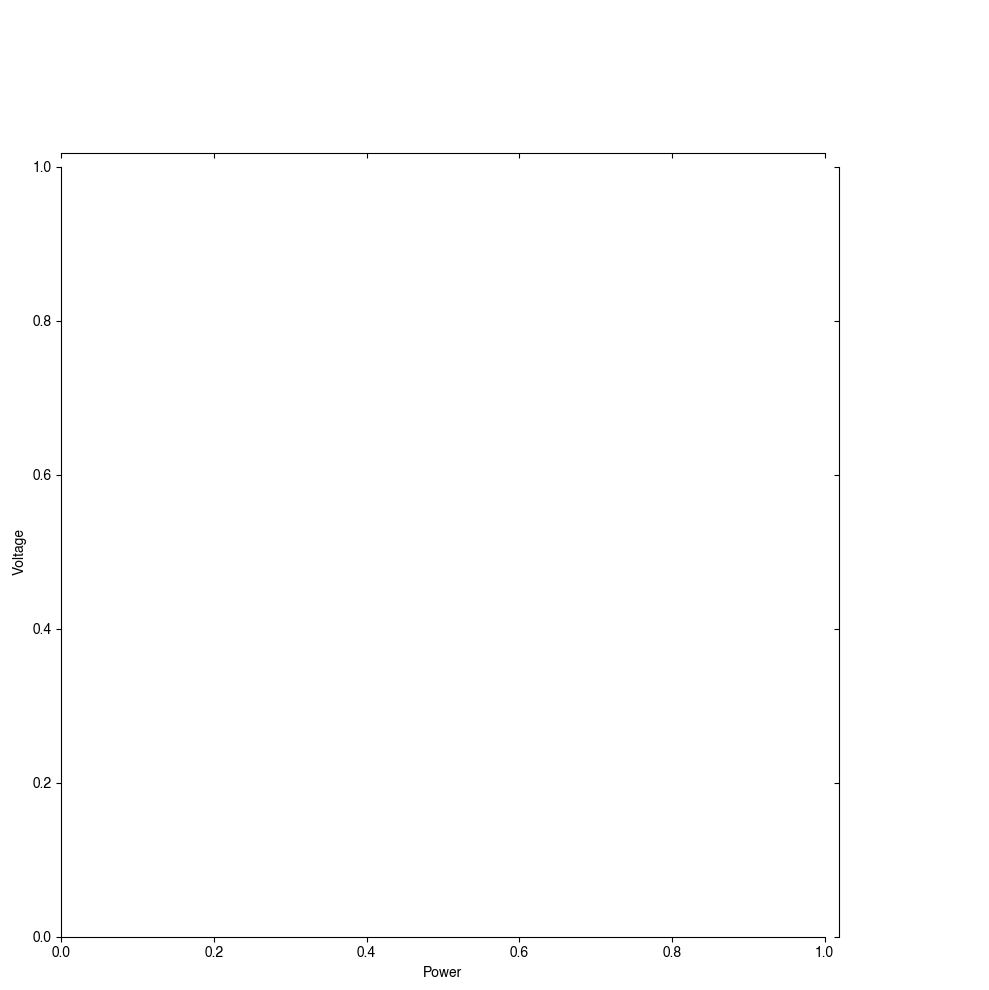

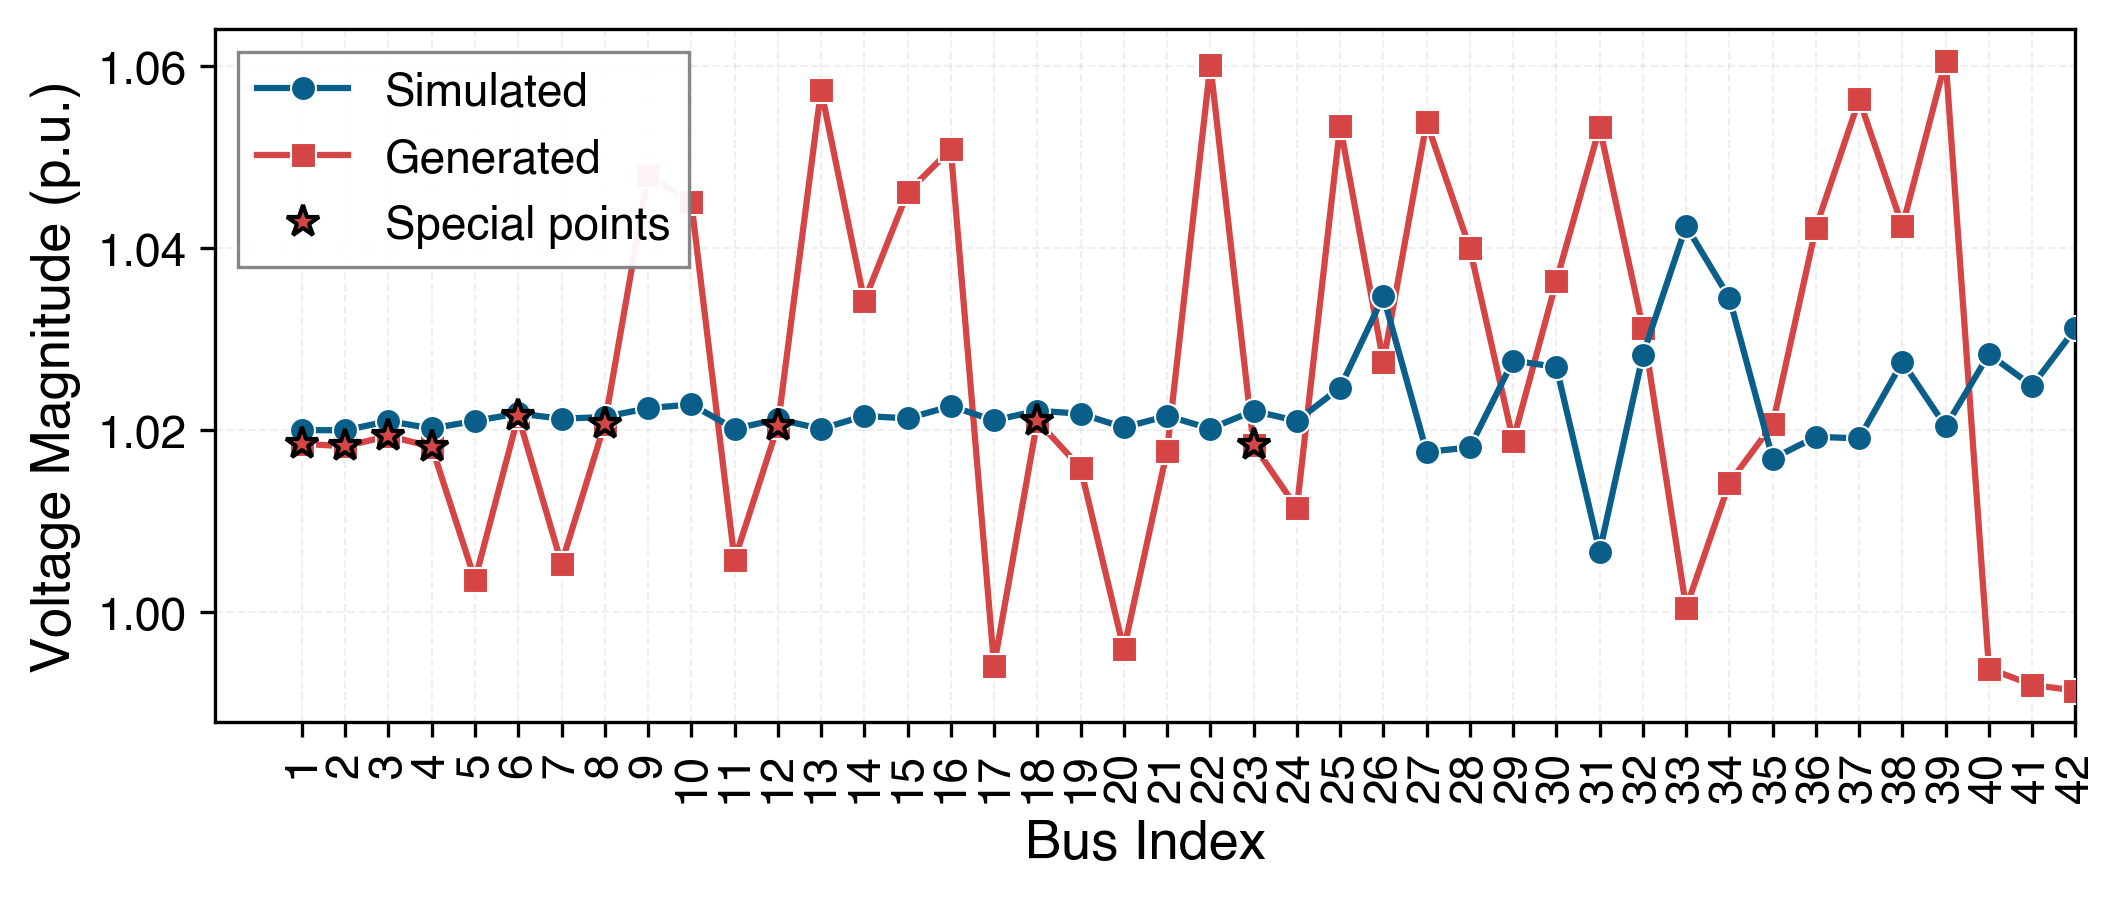

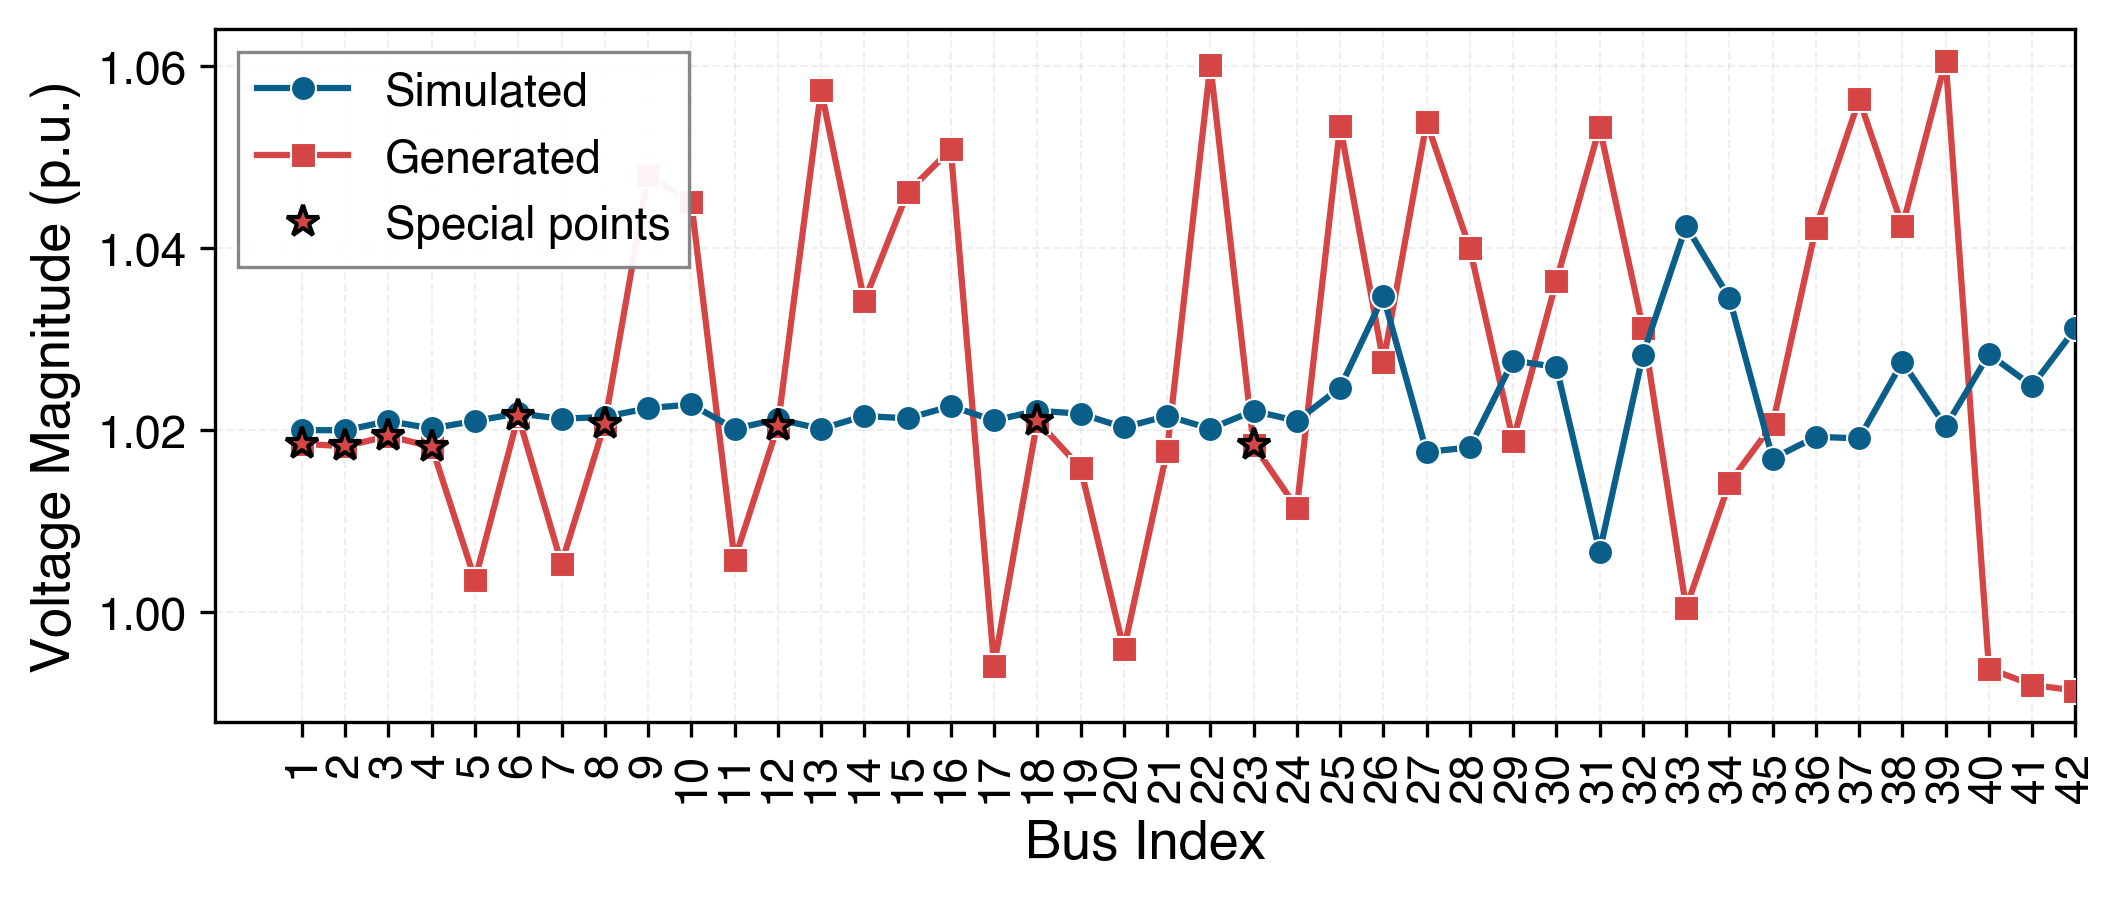

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 3))

# Professional color palette
color_simulated = '#0A5F8A'  # Deep blue
color_generated = '#D64545'  # Warm red
fill_sim = '#5BA3C7'  # Light blue
fill_gen = '#E89B9B'  # Light red

x = np.arange(len(sim_v)) + 1

# Plot simulated data (markers only)
ax.plot(x, sim_v, 
        color=color_simulated, 
        marker='o',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Simulated',
        zorder=4)
# ax.fill_between(x, 
#                 simulated_mean - simulated_std, 
#                 simulated_mean + simulated_std, 
#                 color=fill_sim,
#                 alpha=0.3,
#                 linewidth=0,
#                 zorder=2)

# Plot generated data (markers only)
ax.plot(x, gen_v, 
        color=color_generated, 
        marker='s',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Generated',
        zorder=3)

x_at_meas = np.array([0,1,2,3,5,7,11,17,22]) + 1

# overlay special markers at x_at_meas
mask = np.isin(x, x_at_meas)   # find which x values are in x_at_meas
ax.plot(
    x[mask], gen_v[mask], 
    marker='*',               # change this to any marker ('^', '*', 'D', etc.)
    markersize=8,
    linestyle='None',
    markeredgewidth=1,
    markeredgecolor='black',
    color=color_generated,
    zorder=4,
    label='Special points'
)


# ax.fill_between(x, 
#                 generated_mean - generated_std, 
#                 generated_mean + generated_std, 
#                 color=fill_gen,
#                 alpha=0.3,
#                 linewidth=0,
#                 zorder=1)

# Labels with proper formatting
ax.set_xlabel('Bus Index', fontweight='normal')
ax.set_ylabel('Voltage Magnitude (p.u.)', fontweight='normal')
# ax.set_title('Comparison of Simulated and Generated Voltage Profiles', 
#              fontweight='semibold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(-1,42)

# Clean up spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Optional: Add reference line at 1.0 p.u. (nominal voltage)
# ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.2, 
#            alpha=0.6, zorder=1, label='Nominal (1.0 p.u.)')

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout
# plt.tight_layout(pad=0.5)

# Save options
plt.savefig('FIG_voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

In [13]:
# save the generator model
gen_minus_sim = generated_data['gen_v'][:len(net.bus)] - simulated_v_pf
np.sum(np.abs(gen_minus_sim))

np.float64(0.773431259949666)

In [14]:
torch.save(model_G.state_dict(), parent_dir + f"/results/Best_G.pth")